# Simple Mesh Demo

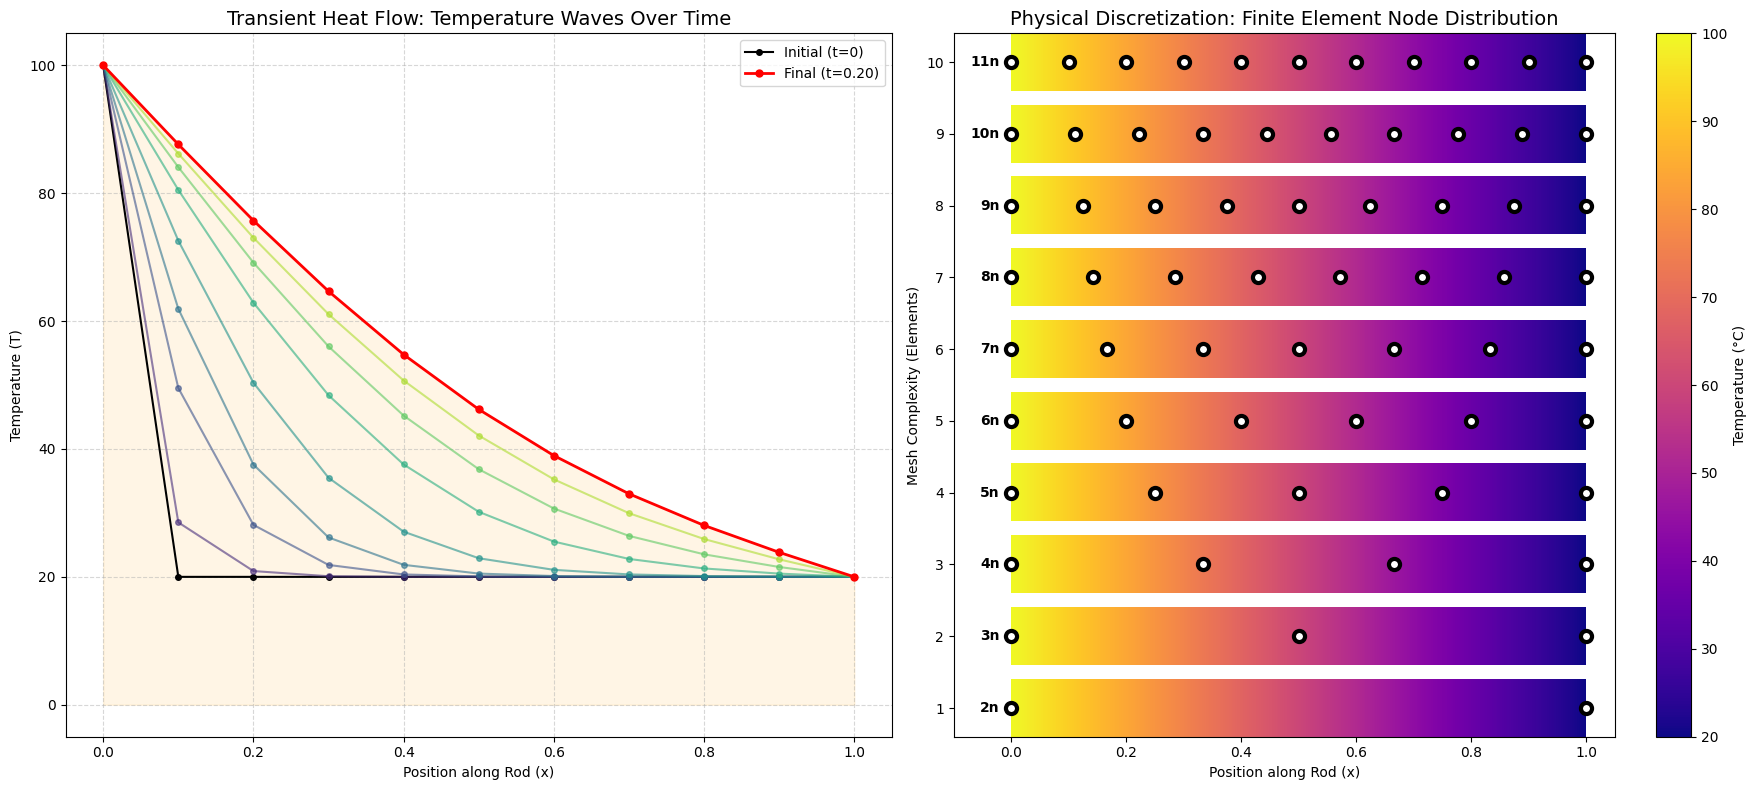

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# 1. Physical and Mesh Parameters
L = 1.0          # Length of rod
k = 1.0          # Thermal conductivity
rho = 1.0        # Density
cp = 1.5         # Specific heat
alpha = k / (rho * cp)  # Thermal diffusivity

# Boundary Conditions
T0_left = 100.0  # Hot end
T0_right = 20.0  # Cold end

# Simulation Settings for the Left Plot (Time Waves)
dt = 0.002       
time_steps = 100 
num_elements_wave = 10  # Keeping the wave plot at a stable 11 nodes
num_nodes_wave = num_elements_wave + 1
x_wave = np.linspace(0, L, num_nodes_wave)
h_wave = x_wave[1] - x_wave[0]

# --- PART 1: TRANSIENT SOLVER (For Left Plot) ---
T = np.full(num_nodes_wave, T0_right)
T[0] = T0_left
T_snapshots = [T.copy()]
times_snapshots = [0.0]

# Backward Euler Setup
diag = np.full(num_nodes_wave - 2, -2.0 / h_wave**2)
off_diag = np.full(num_nodes_wave - 3, 1.0 / h_wave**2)
K_prime = np.diag(diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
A = np.eye(num_nodes_wave - 2) - alpha * dt * K_prime

for step in range(1, time_steps + 1):
    RHS = T[1:-1].copy()
    RHS[0] -= (-1.0 * alpha * dt / h_wave**2) * T0_left
    RHS[-1] -= (-1.0 * alpha * dt / h_wave**2) * T0_right
    T[1:-1] = np.linalg.solve(A, RHS)
    
    if step in [1, 5, 10, 20, 40, 60, 80, 100]:
        T_snapshots.append(T.copy())
        times_snapshots.append(step * dt)

# --- PART 2: VISUALIZATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
cmap = plt.cm.plasma

# LEFT PLOT: Time Evolution Waves
colors_wave = plt.cm.viridis(np.linspace(0, 1, len(T_snapshots)))
x_smooth = np.linspace(0, L, 500)

for i, (T_snap, t_val) in enumerate(zip(T_snapshots, times_snapshots)):
    if i == 0:
        ax1.plot(x_wave, T_snap, 'o-', color='black', linewidth=1.5, markersize=4, label='Initial (t=0)')
    elif i == len(T_snapshots) - 1:
        ax1.plot(x_wave, T_snap, 'ro-', linewidth=2, markersize=5, label=f'Final (t={t_val:.2f})')
    else:
        ax1.plot(x_wave, T_snap, 'o-', color=colors_wave[i], alpha=0.6, markersize=4)

# Shading for the final wave
f_final = interp1d(x_wave, T_snapshots[-1], kind='linear')
ax1.fill_between(x_smooth, 0, f_final(x_smooth), alpha=0.1, color='orange')

ax1.set_title('Transient Heat Flow: Temperature Waves Over Time', fontsize=14)
ax1.set_xlabel('Position along Rod (x)')
ax1.set_ylabel('Temperature (T)')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right')

# RIGHT PLOT: Mesh Complexity (Node Rows)
element_counts = range(1, num_nodes_wave)
for num_elements in element_counts:
    num_nodes = num_elements + 1
    x_nodes = np.linspace(0, L, num_nodes)
    T_nodes = np.linspace(T0_left, T0_right, num_nodes) # Steady state linear gradient
    
    y_pos = num_elements 
    T_fine = np.interp(x_smooth, x_nodes, T_nodes)
    
    ax2.imshow(T_fine[np.newaxis, :], aspect='auto', cmap=cmap, 
               extent=[0, L, y_pos - 0.4, y_pos + 0.4], vmin=T0_right, vmax=T0_left)
    ax2.plot(x_nodes, np.full_like(x_nodes, y_pos), 
         marker='o',             # Use circle markers
         markerfacecolor='white', # The 'empty' effect
         markeredgecolor='black', # Keep the border visible
         markeredgewidth=3,    # A slightly thicker rim for contrast
         markersize=8,           # Maintain the original size
         linestyle='None')
    ax2.text(-0.02, y_pos, f'{num_nodes}n', va='center', ha='right', fontweight='bold')

ax2.set_title('Physical Discretization: Finite Element Node Distribution', fontsize=14)
ax2.set_xlabel('Position along Rod (x)')
ax2.set_ylabel('Mesh Complexity (Elements)')
ax2.set_yticks(element_counts)
ax2.set_xlim(-0.1, 1.05)

# Shared Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T0_right, vmax=T0_left))
cbar = fig.colorbar(sm, ax=ax2, pad=0.05)
cbar.set_label('Temperature (°C)')

plt.tight_layout()
plt.show()

# Mesh Convergence of increasing Nodes

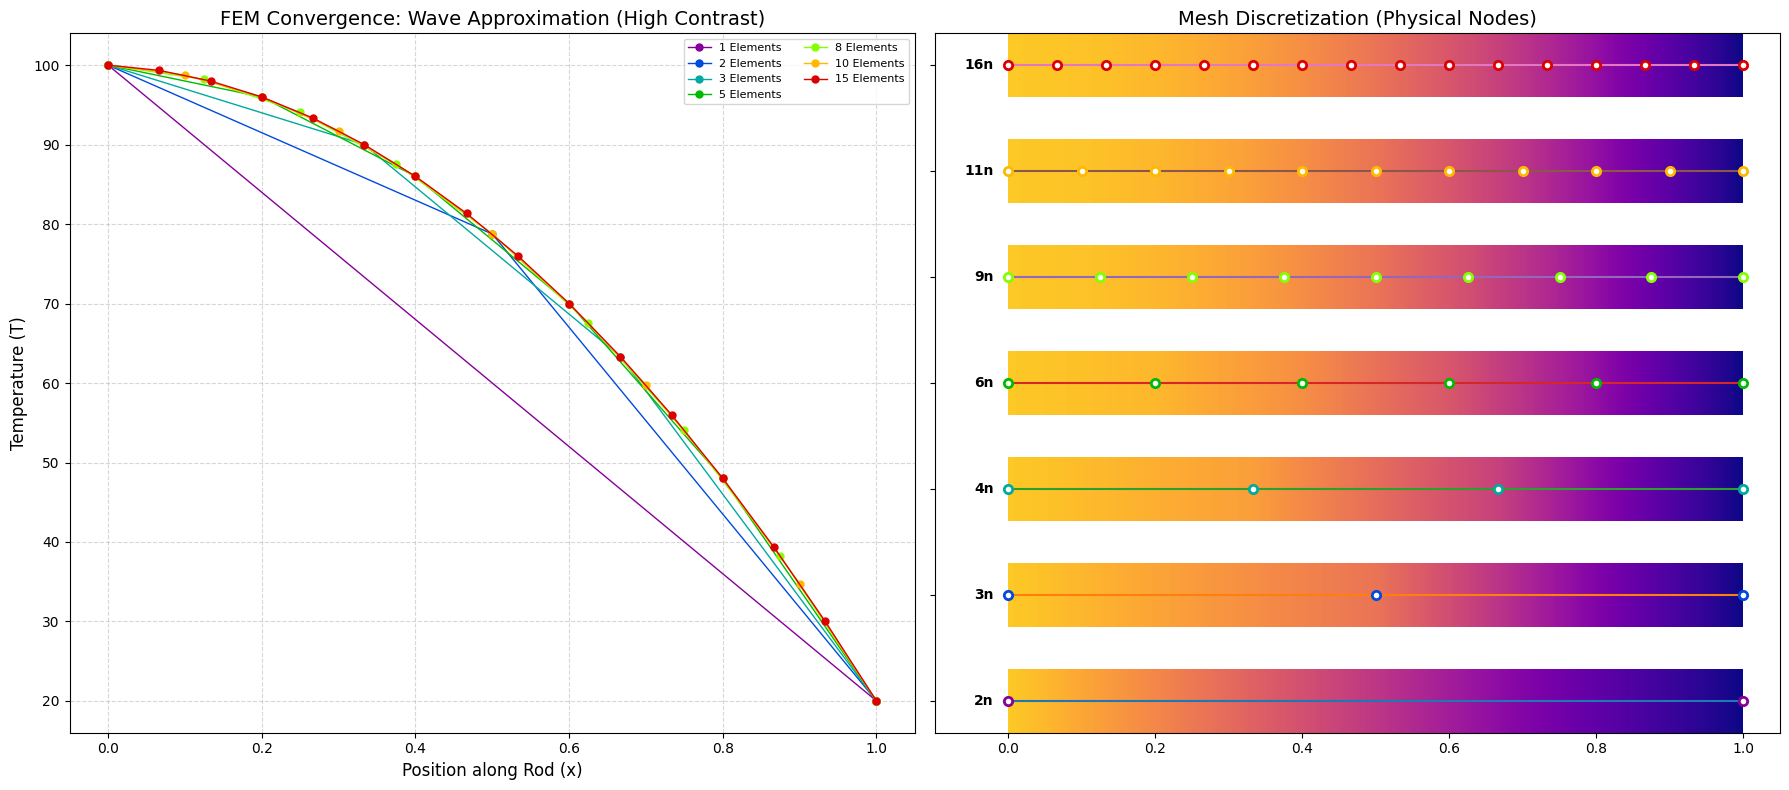

In [141]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Physical Parameters
L, k, T0, TL, Q_source = 1.0, 1.0, 100, 20, 150.0 

# Explicit counts to highlight convergence gaps
element_counts = [1, 2, 3, 5, 8, 10, 15] 

# 2. Use 'nipy_spectral' for the highest-contrast rainbow effect.
# We slice it to skip the initial black so we start with deep purples.
colors = plt.cm.nipy_spectral(np.linspace(0.1, 0.9, len(element_counts)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

for i, num_elements in enumerate(element_counts):
    num_nodes = num_elements + 1
    x = np.linspace(0, L, num_nodes)
    h = L / num_elements
    
    # FEM SOLVER
    K = np.zeros((num_nodes, num_nodes))
    F = np.zeros(num_nodes)
    for e in range(num_elements):
        K[e:e+2, e:e+2] += (k / h) * np.array([[1, -1], [-1, 1]])
        F[e:e+2] += (Q_source * h / 2.0) * np.array([1, 1])

    if num_elements > 1:
        K_int = K[1:-1, 1:-1]
        F_int = F[1:-1] - (K[1:-1, 0] * T0) - (K[1:-1, -1] * TL)
        T_sol = np.concatenate(([T0], np.linalg.solve(K_int, F_int), [TL]))
    else:
        T_sol = np.array([T0, TL])

    # --- LEFT PLOT (CONVERGENCE) ---
    # Coarse models (low nodes) get thin lines; refined models (high nodes) get thick lines.
    lw = 1 + (i * 0.4) 
    ax1.plot(x, T_sol, 'o-', color=colors[i], 
             label=f'{num_elements} Elements', linewidth=1, markersize=5)

    # --- RIGHT PLOT (ROD VISUAL) ---
    y_pos = i  # Stacking for clarity
    x_fine = np.linspace(0, L, 300)
    T_fine = np.interp(x_fine, x, T_sol)
    
    # Rod uses plasma for heat visual, but nodes use our new rainbow colors.
    ax2.imshow(T_fine[np.newaxis, :], aspect='auto', cmap='plasma', 
               extent=[0, L, y_pos - 0.3, y_pos + 0.3], vmin=20, vmax=110)
    
    # Empty nodes with colored rims for maximum contrast.
    ax2.plot(x, np.full_like(x, y_pos), marker='o', 
             markerfacecolor='white', markeredgecolor=colors[i], 
             markeredgewidth=2, markersize=6)
    
    ax2.text(-0.02, y_pos, f'{num_nodes}n', va='center', ha='right', fontweight='bold', fontsize=10)

# Formatting
ax1.set_title('FEM Convergence: Wave Approximation (High Contrast)', fontsize=14)
ax1.set_xlabel('Position along Rod (x)', fontsize=12)
ax1.set_ylabel('Temperature (T)', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(ncol=2, fontsize=8) # 2-column legend to stay compact

ax2.set_title('Mesh Discretization (Physical Nodes)', fontsize=14)
ax2.set_yticks(range(len(element_counts)))
ax2.set_yticklabels([]) # Hide default y-ticks
ax2.set_xlim(-0.1, 1.05)

plt.tight_layout()
plt.savefig("Project_Image_1", bbox_inches='tight')
plt.show()

# Fix Space and Fix Time

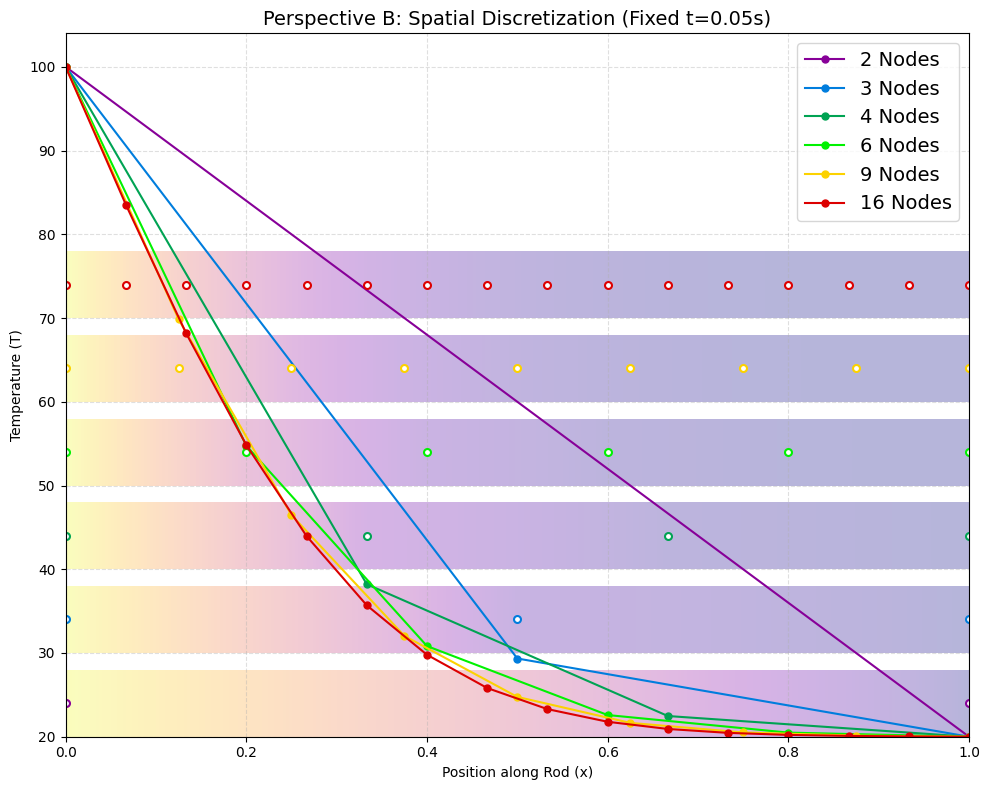

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# 1. Physical Parameters (Unified for both perspectives)
L, k, rho, cp = 1.0, 1.0, 1.0, 1.5
c
T0_left, T0_right = 100.0, 20.0
dt = 0.001
target_time = 0.05  # The "Snapshot" time for the right graph

def solve_transient(num_elements, total_time, dt_val):
    num_nodes = num_elements + 1
    x = np.linspace(0, L, num_nodes)
    h = L / num_elements
    T = np.full(num_nodes, T0_right)
    T[0] = T0_left
    
    steps = int(total_time / dt_val)
    
    # We only build the matrix if there are interior nodes (num_elements > 1)
    if num_elements > 1:
        diag = np.full(num_nodes - 2, -2.0 / h**2)
        off_diag = np.full(num_nodes - 3, 1.0 / h**2)
        K_prime = np.diag(diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)
        A = np.eye(num_nodes - 2) - alpha * dt_val * K_prime

        history = [(0.0, T.copy())]
        for s in range(1, steps + 1):
            RHS = T[1:-1].copy()
            # Boundary adjustments
            RHS[0] -= (-1.0 * alpha * dt_val / h**2) * T0_left
            RHS[-1] -= (-1.0 * alpha * dt_val / h**2) * T0_right
            T[1:-1] = np.linalg.solve(A, RHS)
            history.append((s * dt_val, T.copy()))
    else:
        # Case for 1 element: Linear interpolation between boundaries
        history = [(0.0, T.copy())]
        for s in range(1, steps + 1):
            # In a 1-element model, the "wave" is just a straight line
            history.append((s * dt_val, T.copy()))
            
    return x, history

# --- EXECUTION ---
fig1, ax1 = plt.subplots(figsize=(10, 8))

# LEFT: Perspective A - Temporal Evolution (Fixed Mesh: 15 elements)
x_fixed, wave_history = solve_transient(15, 0.2, dt)
indices = [0, 2, 5, 10, 20, 50, 100, 200]
colors_time = plt.cm.nipy_spectral(np.linspace(0.1, 0.9, len(indices)))

for i, idx in enumerate(indices):
    t_val, T_snap = wave_history[idx]
    ax1.plot(x_fixed, T_snap, 'o-', color=colors_time[i], 
             label=f"t={t_val:.3f}s", markersize=4, alpha=0.8)

ax1.set_title("Perspective A: Temporal Evolution (Fixed 16 Nodes)", fontsize=14)
ax1.set_xlabel("Position along Rod (x)")
ax1.set_ylabel("Temperature (T)")
ax1.legend(fontsize=14, ncol=1)
ax1.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig("Perspective_A_Temporal.png", bbox_inches='tight')
plt.close(fig1)

# RIGHT: Perspective B - Spatial Discretization (Fixed Time: 0.05s)
fig2, ax2 = plt.subplots(figsize=(10, 8))
element_counts = [1, 2, 3, 5, 8, 15]
colors_res = plt.cm.nipy_spectral(np.linspace(0.1, 0.9, len(element_counts)))

for i, n_elem in enumerate(element_counts):
    x_var, hist_var = solve_transient(n_elem, target_time, dt)
    _, T_final = hist_var[-1]
    
    # Plot curves
    ax2.plot(x_var, T_final, 'o-', color=colors_res[i], 
             label=f"{n_elem+1} Nodes", markersize=5)
    
    # Rod Visuals (Rainbow Bars) in background
    y_pos = i
    x_fine = np.linspace(0, L, 300)
    T_fine = np.interp(x_fine, x_var, T_final)
    ax2.imshow(T_fine[np.newaxis, :], aspect='auto', cmap='plasma', 
               extent=[0, L, y_pos*10 + 20, y_pos*10 + 28], vmin=20, vmax=100, alpha=0.3)
    
    # Add empty nodes (white center) for maximum contrast
    ax2.plot(x_var, np.full_like(x_var, y_pos*10 + 24), marker='o', 
             markerfacecolor='white', markeredgecolor=colors_res[i], 
             markeredgewidth=1.5, markersize=5, linestyle='None')

ax2.set_title(f"Perspective B: Spatial Discretization (Fixed t={target_time}s)", fontsize=14)
ax2.set_xlabel("Position along Rod (x)")
ax2.set_ylabel("Temperature (T)")
ax2.legend(fontsize=14)
ax2.grid(True, ls='--', alpha=0.4)

plt.tight_layout()
plt.savefig("Perspective_B_Spatial.png", bbox_inches='tight')


# Middle Two Tube Heat Diagrams

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import os

# 1. Geometry Dimensions
L = 20.0
R = 5.0  
segments = 100 

# 2. Generate the Cylinder Mesh
x = np.linspace(0, L, segments)
theta = np.linspace(0, 2 * np.pi, 60)
X, THETA = np.meshgrid(x, theta)

Y = R * np.cos(THETA)
Z = R * np.sin(THETA)

# 3. Define the Heat Equation Model (Linear Gradient)
T_start = 100.0
T_end = 20.0

# Linear temperature distribution: T(x)
temp_profile = T_start + (x / L) * (T_end - T_start)

# Map temperatures to a 0-1 scale for the colormap
# (temp - min) / (max - min)
temp_norm = (temp_profile - T_end) / (T_start - T_end)
temp_mesh = np.tile(temp_norm, (len(theta), 1))

# 4. Rendering
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111, projection='3d')

# Render the surface using the linear temperature gradient
surf = ax.plot_surface(X, Y, Z, facecolors=plt.cm.turbo(temp_mesh),
                       antialiased=True, shade=False)

# 5. Framing & Perspective
ax.set_box_aspect((4, 1, 1)) # Forces the 20ft length to look long
ax.set_xlim(0, L)
ax.set_ylim(-L/2, L/2)
ax.set_zlim(-L/2, L/2)
ax.set_axis_off()

# Colorbar - Updated to show actual Fahrenheit values
sm = plt.cm.ScalarMappable(cmap=plt.cm.turbo)
sm.set_array([T_end, T_start]) # Set range from 20 to 100
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Temperature (°F)', rotation=270, labelpad=20)

# 6. Save and Post-Process Crop
temp_file = "temp_heat_render.png"
final_file = "heat_equation_tube.png"

plt.savefig(temp_file, bbox_inches='tight', pad_inches=0, transparent=True)
plt.close()

# 7. Auto-Crop
try:
    img = Image.open(temp_file)
    bbox = img.getbbox()
    if bbox:
        img_cropped = img.crop(bbox)
        img_cropped.save(final_file)
        print(f"Success! Heat model saved to: {final_file}")
        os.remove(temp_file)
except Exception as e:
    print(f"Error during cropping: {e}")

Success! Heat model saved to: heat_equation_tube.png


#  older version

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import os

# 1. Geometry Dimensions
L = 20.0
R = 5.0  
segments = 100 

# 2. Generate the Cylinder Mesh
x = np.linspace(0, L, segments)
theta = np.linspace(0, 2 * np.pi, 60)
X, THETA = np.meshgrid(x, theta)
Y = R * np.cos(THETA)
Z = R * np.sin(THETA)

# 3. Define the Heat Equation Model
T_start = 100.0  # Try changing this to 200.0 now!
T_end = 20.0

# Define a FIXED global scale for comparison
ABS_MIN = 20.0
ABS_MAX = 100.0

# Linear temperature distribution
temp_profile = T_start + (x / L) * (T_end - T_start)

# CRITICAL CHANGE: Normalize based on ABSOLUTE bounds, not local bounds
temp_norm = (temp_profile - ABS_MIN) / (ABS_MAX - ABS_MIN)
temp_mesh = np.tile(temp_norm, (len(theta), 1))

# 4. Rendering
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, facecolors=plt.cm.turbo(temp_mesh),
                       antialiased=True, shade=False)

# 5. Framing & Perspective
ax.set_box_aspect((4, 1, 1))
ax.set_xlim(0, L)
ax.set_ylim(-L/2, L/2)
ax.set_zlim(-L/2, L/2)
ax.set_axis_off()

# Colorbar - Set to the FIXED absolute range
sm = plt.cm.ScalarMappable(cmap=plt.cm.turbo)
sm.set_array([ABS_MIN, ABS_MAX]) 
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Temperature (°F)', rotation=270, labelpad=20)

# 6. Save and Post-Process Crop
temp_file = "temp_heat_render.png"
final_file = "heat_equation_tube_high.png"

plt.savefig(temp_file, bbox_inches='tight', pad_inches=0, transparent=True)
plt.close()

# 7. Auto-Crop
try:
    img = Image.open(temp_file)
    bbox = img.getbbox()
    if bbox:
        img_cropped = img.crop(bbox)
        img_cropped.save(final_file)
        print(f"Success! Model saved with absolute scale: {final_file}")
        os.remove(temp_file)
except Exception as e:
    print(f"Error: {e}")

Success! Model saved with absolute scale: heat_equation_tube_high.png


# another older version

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import os

# 1. Geometry Dimensions
L = 20.0
R = 5.0  
segments = 100

# 2. Generate the Cylinder Mesh
x = np.linspace(0, L, segments)
theta = np.linspace(0, 2 * np.pi, 60)
X, THETA = np.meshgrid(x, theta)
Y = R * np.cos(THETA)
Z = R * np.sin(THETA)

# 3. Define the Heat Equation Model
T_start = 100.0  # Try changing this to 200.0 now!
T_end = 20.0

# Define a FIXED global scale for comparison
ABS_MIN = 20.0
ABS_MAX = 100.0

# Linear temperature distribution
temp_profile = T_start + (x / L) * (T_end - T_start)

# CRITICAL CHANGE: Normalize based on ABSOLUTE bounds, not local bounds
temp_norm = (temp_profile - ABS_MIN) / (ABS_MAX - ABS_MIN)
temp_mesh = np.tile(temp_norm, (len(theta), 1))

# 4. Rendering
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z, facecolors=plt.cm.turbo(temp_mesh),
                       antialiased=False, # Antialiasing can cause "white spiderwebs" at high segments
                       shade=False, 
                       rcount=segments, 
                       ccount=60)

# 5. Framing & Perspective
ax.set_box_aspect((4, 1, 1))
ax.set_xlim(0, L)
ax.set_ylim(-L/2, L/2)
ax.set_zlim(-L/2, L/2)
ax.set_axis_off()

# Colorbar - Set to the FIXED absolute range
sm = plt.cm.ScalarMappable(cmap=plt.cm.turbo)
sm.set_array([ABS_MIN, ABS_MAX]) 
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Temperature (°F)', rotation=270, labelpad=20)

# 6. Save and Post-Process Crop
temp_file = "temp_heat_render.png"
final_file = "heat_equation_tube_100segments.png"

plt.savefig(temp_file, bbox_inches='tight', pad_inches=0, transparent=True)
plt.close()

# 7. Auto-Crop
try:
    img = Image.open(temp_file)
    bbox = img.getbbox()
    if bbox:
        img_cropped = img.crop(bbox)
        img_cropped.save(final_file)
        print(f"Success! Model saved with absolute scale: {final_file}")
        os.remove(temp_file)
except Exception as e:
    print(f"Error: {e}")

Success! Model saved with absolute scale: heat_equation_tube_100segments.png


# Heat Equation Tube Diagram

In [136]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import os

# --- 1. Simulation Parameters (The Heat Equation) ---
L = 20.0
num_nodes = 51  # This matches your 'segments'
h = L / (num_nodes - 1)
alpha = 0.2     # Thermal diffusivity
dt_val = 0.5     # Time step
steps = 3000      # Total time steps to evolve

# Boundary Conditions
T0_left = 100.0
T0_right = 20.0

# Initialize Temperature (Start everything at 20, except the hot end)
T = np.full(num_nodes, 20.0)
T[0] = T0_left
T[-1] = T0_right

# --- 2. Solve the Implicit System (Backward Euler) ---
# Constructing Matrix A: (I - alpha * dt * K)
diag = np.full(num_nodes - 2, 1.0 + 2.0 * alpha * dt_val / h**2)
off_diag = np.full(num_nodes - 3, -alpha * dt_val / h**2)
A = np.diag(diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)

for s in range(1, steps + 1):
    RHS = T[1:-1].copy()
    # Boundary adjustments for the implicit solver
    RHS[0] += (alpha * dt_val / h**2) * T0_left
    RHS[-1] += (alpha * dt_val / h**2) * T0_right
    T[1:-1] = np.linalg.solve(A, RHS)

# --- 3. Generate 3D Mesh ---
R = 5.0
theta_res = 60
x_coords = np.linspace(0, L, num_nodes)
theta = np.linspace(0, 2 * np.pi, theta_res)
X, THETA = np.meshgrid(x_coords, theta)

Y = R * np.cos(THETA)
Z = R * np.sin(THETA)

# --- 4. Map Simulation Data to Colors ---
# Normalize based on your 20-100 range
temp_norm = (T - 20) / (100 - 20)
temp_mesh = np.tile(temp_norm, (theta_res, 1))

# --- 5. Rendering ---
fig = plt.figure(figsize=(18, 8))
ax = fig.add_subplot(111, projection='3d')
"""
surf = ax.plot_surface(X, Y, Z, facecolors=plt.cm.turbo(temp_mesh),
                       antialiased=True, # Essential: True blurs the thin lines
                       shade=False,
                       rcount=theta_res,  # Use all circle points
                       ccount=num_nodes)  # Use all 1000+ heat nodes
"""
ax.set_box_aspect((8, 1, 1))
#ax.view_init(elev=20, azim=-60)
ax.set_box_aspect((4, 1, 1))
ax.set_xlim(0, L)
ax.set_ylim(-L/2, L/2)
ax.set_zlim(-L/2, L/2)
ax.set_axis_off()

# Colorbar
#sm = plt.cm.ScalarMappable(cmap=plt.cm.turbo)
#sm.set_array([20, 100])
#cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
#cbar.set_label('Temperature (°F)', rotation=270, labelpad=20)

# --- 1. Create a "Dummy" Axis for the Segment Scale ---
# [left, bottom, width, height] in figure coordinates
# Adjust the first number (0.85) to move it left/right
ax_ticks = fig.add_axes([0.88, 0.3, 0.01, 0.4]) 

# --- 2. Define your segments (Labels) ---
segments = ["2000","1000", "500", "200", "100", "50", "20"]
n = len(segments)

# --- 3. Style the Scale ---
# Create equal spacing from 0 to 1
y_positions = np.linspace(0, 20, n)

ax_ticks.set_ylim(0, 1)
ax_ticks.set_xticks([]) # Hide X-axis
ax_ticks.set_yticks(y_positions)
ax_ticks.set_yticklabels(segments)

# Set the spine (the vertical line) to black
ax_ticks.spines['top'].set_visible(False)
ax_ticks.spines['bottom'].set_visible(False)
ax_ticks.spines['left'].set_visible(False)
ax_ticks.spines['right'].set_color('black')
ax_ticks.spines['right'].set_linewidth(1.5)

# Style the ticks themselves
ax_ticks.tick_params(axis='y', colors='black', direction='out', length=6, width=1.5)

# Add the label
ax_ticks.set_ylabel('Number of Seconds', rotation=270, labelpad=25, color='black', fontsize=12)

# Make the background transparent so it doesn't block the 3D plot
ax_ticks.patch.set_alpha(0)

# --- 6. Save and Auto-Crop ---
temp_file = "temp_sim_render.png"
final_file = "heat_equation_tube_justtime.png"

plt.savefig(temp_file, bbox_inches='tight', pad_inches=0, transparent=True)
plt.close()

try:
    img = Image.open(temp_file)
    bbox = img.getbbox()
    if bbox:
        img_cropped = img.crop(bbox)
        img_cropped.save(final_file)
        print(f"Success! Transient model saved to: {final_file}")
        os.remove(temp_file)
except Exception as e:
    print(f"Error: {e}")

Success! Transient model saved to: heat_equation_tube_justtime.png
